Import libraries required for the task

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

I now import the data from the titanic csv and create a dataframe from it

In [2]:
titanic_df = pd.read_csv('titanic.csv')
titanic_df.info()
titanic_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The first task is to check if the dataset has any duplicate rows, in this data set there are no duplicates

In [3]:
duplicate_rows = titanic_df[titanic_df.duplicated()]
print("\nDuplicate rows:\n", duplicate_rows)


Duplicate rows:
 Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


From the data set I am dropping the Features Cabin, Name, Ticket and Passenger ID

as I do not believe they will make a meaninigful contribution to the models accuracy

In [4]:
titanic_df.drop(["Cabin",'Name','Ticket','PassengerId'], axis=1, inplace=True)

Next I am using one-hot encoding the create separate columns for the different sex categories

I am dropping the first column to mitigate multicollinearity

In [5]:
titanic_df["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [6]:
# Apply one-hot encoding to the 'Sex' column
titanic_df = pd.get_dummies(titanic_df, prefix="Sex", columns=["Sex"],drop_first=True,dtype=int)
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Sex_male
0,0,3,22.0,1,0,7.2500,S,1
1,1,1,38.0,1,0,71.2833,C,0
2,1,3,26.0,0,0,7.9250,S,0
3,1,1,35.0,1,0,53.1000,S,0
4,0,3,35.0,0,0,8.0500,S,1


The next category column is "Embarked" the location the passengers embarked the boat from

I found that there were 2 passengers where this was unknown that I have removed from the data set

I have then created columns for each of the categories using One-Hot Encoding

In [7]:
titanic_df[titanic_df['Embarked'].isnull()]

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Sex_male
61,1,1,38.0,0,0,80.0,NaN,0
829,1,1,62.0,0,0,80.0,NaN,0


In [8]:
titanic_df = titanic_df.drop(index=[61, 829])
titanic_df = pd.get_dummies(titanic_df, prefix="Embarked", columns=["Embarked"],drop_first=True,dtype=int)
titanic_df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Age         712 non-null    float64
 3   SibSp       889 non-null    int64  
 4   Parch       889 non-null    int64  
 5   Fare        889 non-null    float64
 6   Sex_male    889 non-null    int64  
 7   Embarked_Q  889 non-null    int64  
 8   Embarked_S  889 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 69.5 KB


Next is dealing with the null values in the age column

For this I am applying the average age to these null fields

In [9]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())

Now we have the clean data I am doing one final check to make sure

the data doesn't have any material multicollinearity.

Although there is a correlation between Pclass and Fare, which makes sense

given that the wealthier passengers could afford the better cabins,

it's not material enough to remove them.

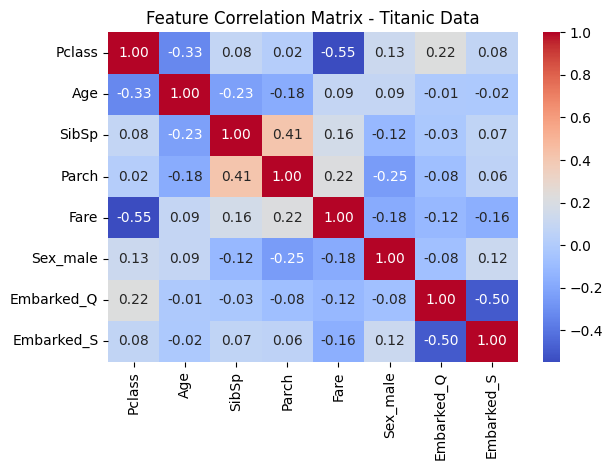

In [10]:
X = titanic_df.drop(columns='Survived')
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix - Titanic Data")
plt.tight_layout()
plt.show()

I now apply the "Survived" column to the y value and the rest the the X value

In [11]:
X = titanic_df.drop(columns=['Survived'])
y = titanic_df['Survived']
X.shape

feature_names = X.columns
feature_names

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

I am using a random state of 42 to ensure the output is the same each time I train the models

I then split the data 70:30, 70% training and 30% testing

In [12]:
#random state
r = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=r)

3. Create a Random Forest to predict the survival rate of passengers

I create a Random Forest Classifier and fit the data to the model

The testing accuracy of the random forest model is 0.764

In [13]:
# Create Random Forest Classifie
rf = RandomForestClassifier(random_state=r)

# Train the RF classifier
rf.fit(X_train,y_train)

#Predict the response for test dataset for the models
y_test_pred_rf = rf.predict(X_test)

print(f'Testing Accuracy for Random Forest model: {accuracy_score(y_test, y_test_pred_rf)}')

Testing Accuracy for Random Forest model: 0.7640449438202247


To find the features that contribute the most to predicting whether a passenger
survives or not I am using a Gini Importance method

A property of the Random Forest ensemble method in sklearn is that they let you print importance scores for features in the dataset.

In [14]:
importances = rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
feature_imp_df

,Feature,Gini Importance
4,Fare,0.277259
1,Age,0.255698
5,Sex_male,0.247946
0,Pclass,0.080746
2,SibSp,0.052062
3,Parch,0.047384
7,Embarked_S,0.027127
6,Embarked_Q,0.011779


Text(0, 0.5, 'Features')

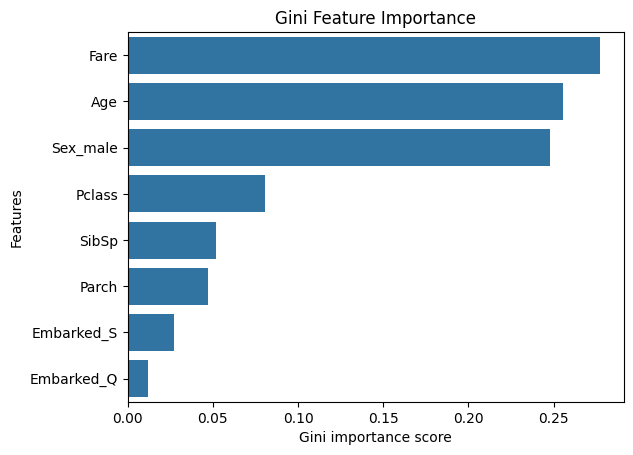

In [15]:
sns.barplot(x=feature_imp_df['Gini Importance'],y=feature_imp_df['Feature'],data=feature_imp_df)
plt.title("Gini Feature Importance")
plt.xlabel("Gini importance score")
plt.ylabel("Features")

From the features the Fare is the most important contributer to determining if a passenger survived or not.

Fare is only marginally more than age and sex as the top 3 features carry a much greater importance than the others.

Given that the Embarked_S and Embarked_Q features contribute very little

to the predictive power of the model I am dropping them from the features list

In [16]:
X_train = X_train.drop(['Embarked_S','Embarked_Q'], axis=1)
X_test = X_test.drop(['Embarked_S','Embarked_Q'], axis=1)
X_test.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male'], dtype='str')

In [17]:
# Hyperparameter tuning for Random Forest using GridSearchCV and fit the data.

params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_split': [5,10,20,50,100,200],
    'max_features': [1,2,3,4,5,6,7,8],
    'n_estimators': [10, 30, 50, 70, 100, 200, 300]
}

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 5,
                           n_jobs=-1, verbose=1, scoring="accuracy")

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1680 candidates, totalling 8400 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'max_features': [1, 2, ...], 'min_samples_split': [5, 10, ...], 'n_estimators': [10, 30, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [18]:
#Predict the response for test dataset for the models
y_test_grid_search = grid_search.predict(X_test)

print(f'Testing Accuracy for Random Forest model: {accuracy_score(y_test, y_test_pred_rf)}')
print(f'Testing Accuracy for Random Forest model with permutation importance: {accuracy_score(y_test, y_test_grid_search)}')

Testing Accuracy for Random Forest model: 0.7640449438202247
Testing Accuracy for Random Forest model with permutation importance: 0.8127340823970037


Using a random forest model with no hyper parameters achieves an accuracy of 0.764.

Using hyperparameters of a max depth of 10 rows, a maximum number of 5 features are considered each split and minimum number of samples per split of 5 gives an accuracy of 0.8127

I am now going to use a Bagging algorithm to optomize the model

Bagging is an extension of Bootstrapping that uses multiple sub samples of the data set

to train the model.

Below I am using a base model with a max depth of 5 and 100 estimators (trees)

Using the Bagging classifier improved on the base case, improving accuracy

from 81.2% to 81.6%, which is a small but positive increase.

In [19]:
# Create base model
base = DecisionTreeClassifier(max_depth=5, random_state=r)

# Create an ensemble model
ensemble = BaggingClassifier(estimator=base, n_estimators=100, random_state=r)

# Fit the base model on the training data
base.fit(X_train,y_train)

# Fit the ensemble model on the training data
ensemble.fit(X_train,y_train)

print("Accuracy base:",base.score(X_test, y_test))
print("Accuracy after applying Bagging Algo:",ensemble.score(X_test, y_test))

Accuracy base: 0.8127340823970037
Accuracy after applying Bagging Algo: 0.8164794007490637


GridSearchCV uses a technique called Cross Validation to identify the optimum

Hyperparamater configuration, below I am using it to find the optimum config.

In [20]:
params = {
    'n_estimators': [10, 30, 50, 70, 100, 200, 300],
    'estimator__max_depth': [2,3,5,10,20]
}

grid = GridSearchCV(BaggingClassifier(estimator=base, random_state=r), 
                    params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassi...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [2, 3, ...], 'n_estimators': [10, 30, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

GridSearchCV has calculated that the optimum config for a model on this data set

is using a maximum depth of 10 and 200 estimators(trees) to find the best model.

Below the difference between the base model and bagging model has been reduced by using

the hyperparameters defined by GridSearchCV

In [21]:
# Create base model
base = DecisionTreeClassifier(max_depth=10, random_state=r)

# Create an ensemble model
ensemble = BaggingClassifier(estimator=base, n_estimators=200, random_state=r)

# Fit the base model on the training data
base.fit(X_train,y_train)

# Fit the ensemble model on the training data
ensemble.fit(X_train,y_train)

print("Accuracy base:",base.score(X_test, y_test))
print("Accuracy using optomized Hyper Parameters:",ensemble.score(X_test, y_test))

Accuracy base: 0.8052434456928839
Accuracy using optomized Hyper Parameters: 0.8089887640449438


Below I am using the Boosting algo to optomize the model

Boosting is an ensemble learning technique that aims to improve

the accuracy of the models by sequentially training the model

on the complete dataset to reduce the errors

In [22]:
gbr = GradientBoostingClassifier(
    n_estimators=200,        # number of boosting stages (trees)
    learning_rate=0.1,       # shrinks each tree's contribution
    max_depth=4,             # depth of each individual tree
    min_samples_leaf=5,      # prevents overfitting on small splits
    subsample=0.8,           # fraction of samples per tree (stochastic GB)
    random_state=42
)

gbr.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

Above I have trained a model using some standard hyperparameters to create 

a base case GradientBoostingClassifer model which has an accuracy below of 0.7978

which is already an improvement on the Random Forest accuracy.


In [23]:
model = GradientBoostingClassifier(
    max_depth=4,
    min_samples_leaf=5,
    n_estimators=200,
    random_state=42,
    subsample=0.8
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Testing Accuracy for Random Forest model: {accuracy_score(y_test, y_test_pred_rf)}')
print(f"Testing Accuracy for using GradientBoosting Classifer: {accuracy_score(y_test, y_pred):.4f}")

Testing Accuracy for Random Forest model: 0.7640449438202247
Testing Accuracy for using GradientBoosting Classifer: 0.7978


I am then using GridSearchCV to find the optimum Hyperparameters like I did for the Bagging Classifier

In [24]:
params = {
    'n_estimators': [10, 30, 50, 70, 100, 200, 300],
    'max_depth': [2, 3, 5, 10, 20]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=r),params,cv=5,scoring='accuracy'
)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 2, 'n_estimators': 70}


In [25]:
model = GradientBoostingClassifier(
    max_depth=2,
    min_samples_leaf=5,
    n_estimators=70,
    random_state=42,
    subsample=0.8,
    learning_rate = 0.05
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Testing Accuracy for Random Forest model: {accuracy_score(y_test, y_test_pred_rf)}')
print(f"Testing Accuracy for GradientBoosting Classifer with optomized Hyperparameters: {accuracy_score(y_test, y_pred):.4f}")

Testing Accuracy for Random Forest model: 0.7640449438202247
Testing Accuracy for GradientBoosting Classifer with optomized Hyperparameters: 0.8202


Using the max_depth and estimators advised by GridSearchCV of 2 and 70

I now have an improved accuracy of 0.8202